Loaded file: LinearData/uncertainty_alignment_10fold_ridge_probe_results.csv
Shape: (868, 22)
Columns:
['model', 'layer', 'human_ent_mean_r2', 'human_ent_fold_r2s', 'human_ent_mean_correlation', 'human_ent_fold_correlations', 'human_ent_mean_mse', 'human_ent_fold_mses', 'rt_correct_mean_r2', 'rt_correct_fold_r2s', 'rt_correct_mean_correlation', 'rt_correct_fold_correlations', 'rt_correct_mean_mse', 'rt_correct_fold_mses', 'rt_combined_mean_r2', 'rt_combined_fold_r2s', 'rt_combined_mean_correlation', 'rt_combined_fold_correlations', 'rt_combined_mean_mse', 'rt_combined_fold_mses', 'n_samples', 'n_features']

Using metric columns:
   human_ent_mean_r2
   human_ent_mean_correlation
   human_ent_mean_mse

Plotting Mistral...

Plotting Llama_2...

Plotting Llama_3...

Plotting Gemma...

Plotting Gemma_2...

Plotting Falcon_3_1B_3B...

Plotting Falcon_3_7B_10B...


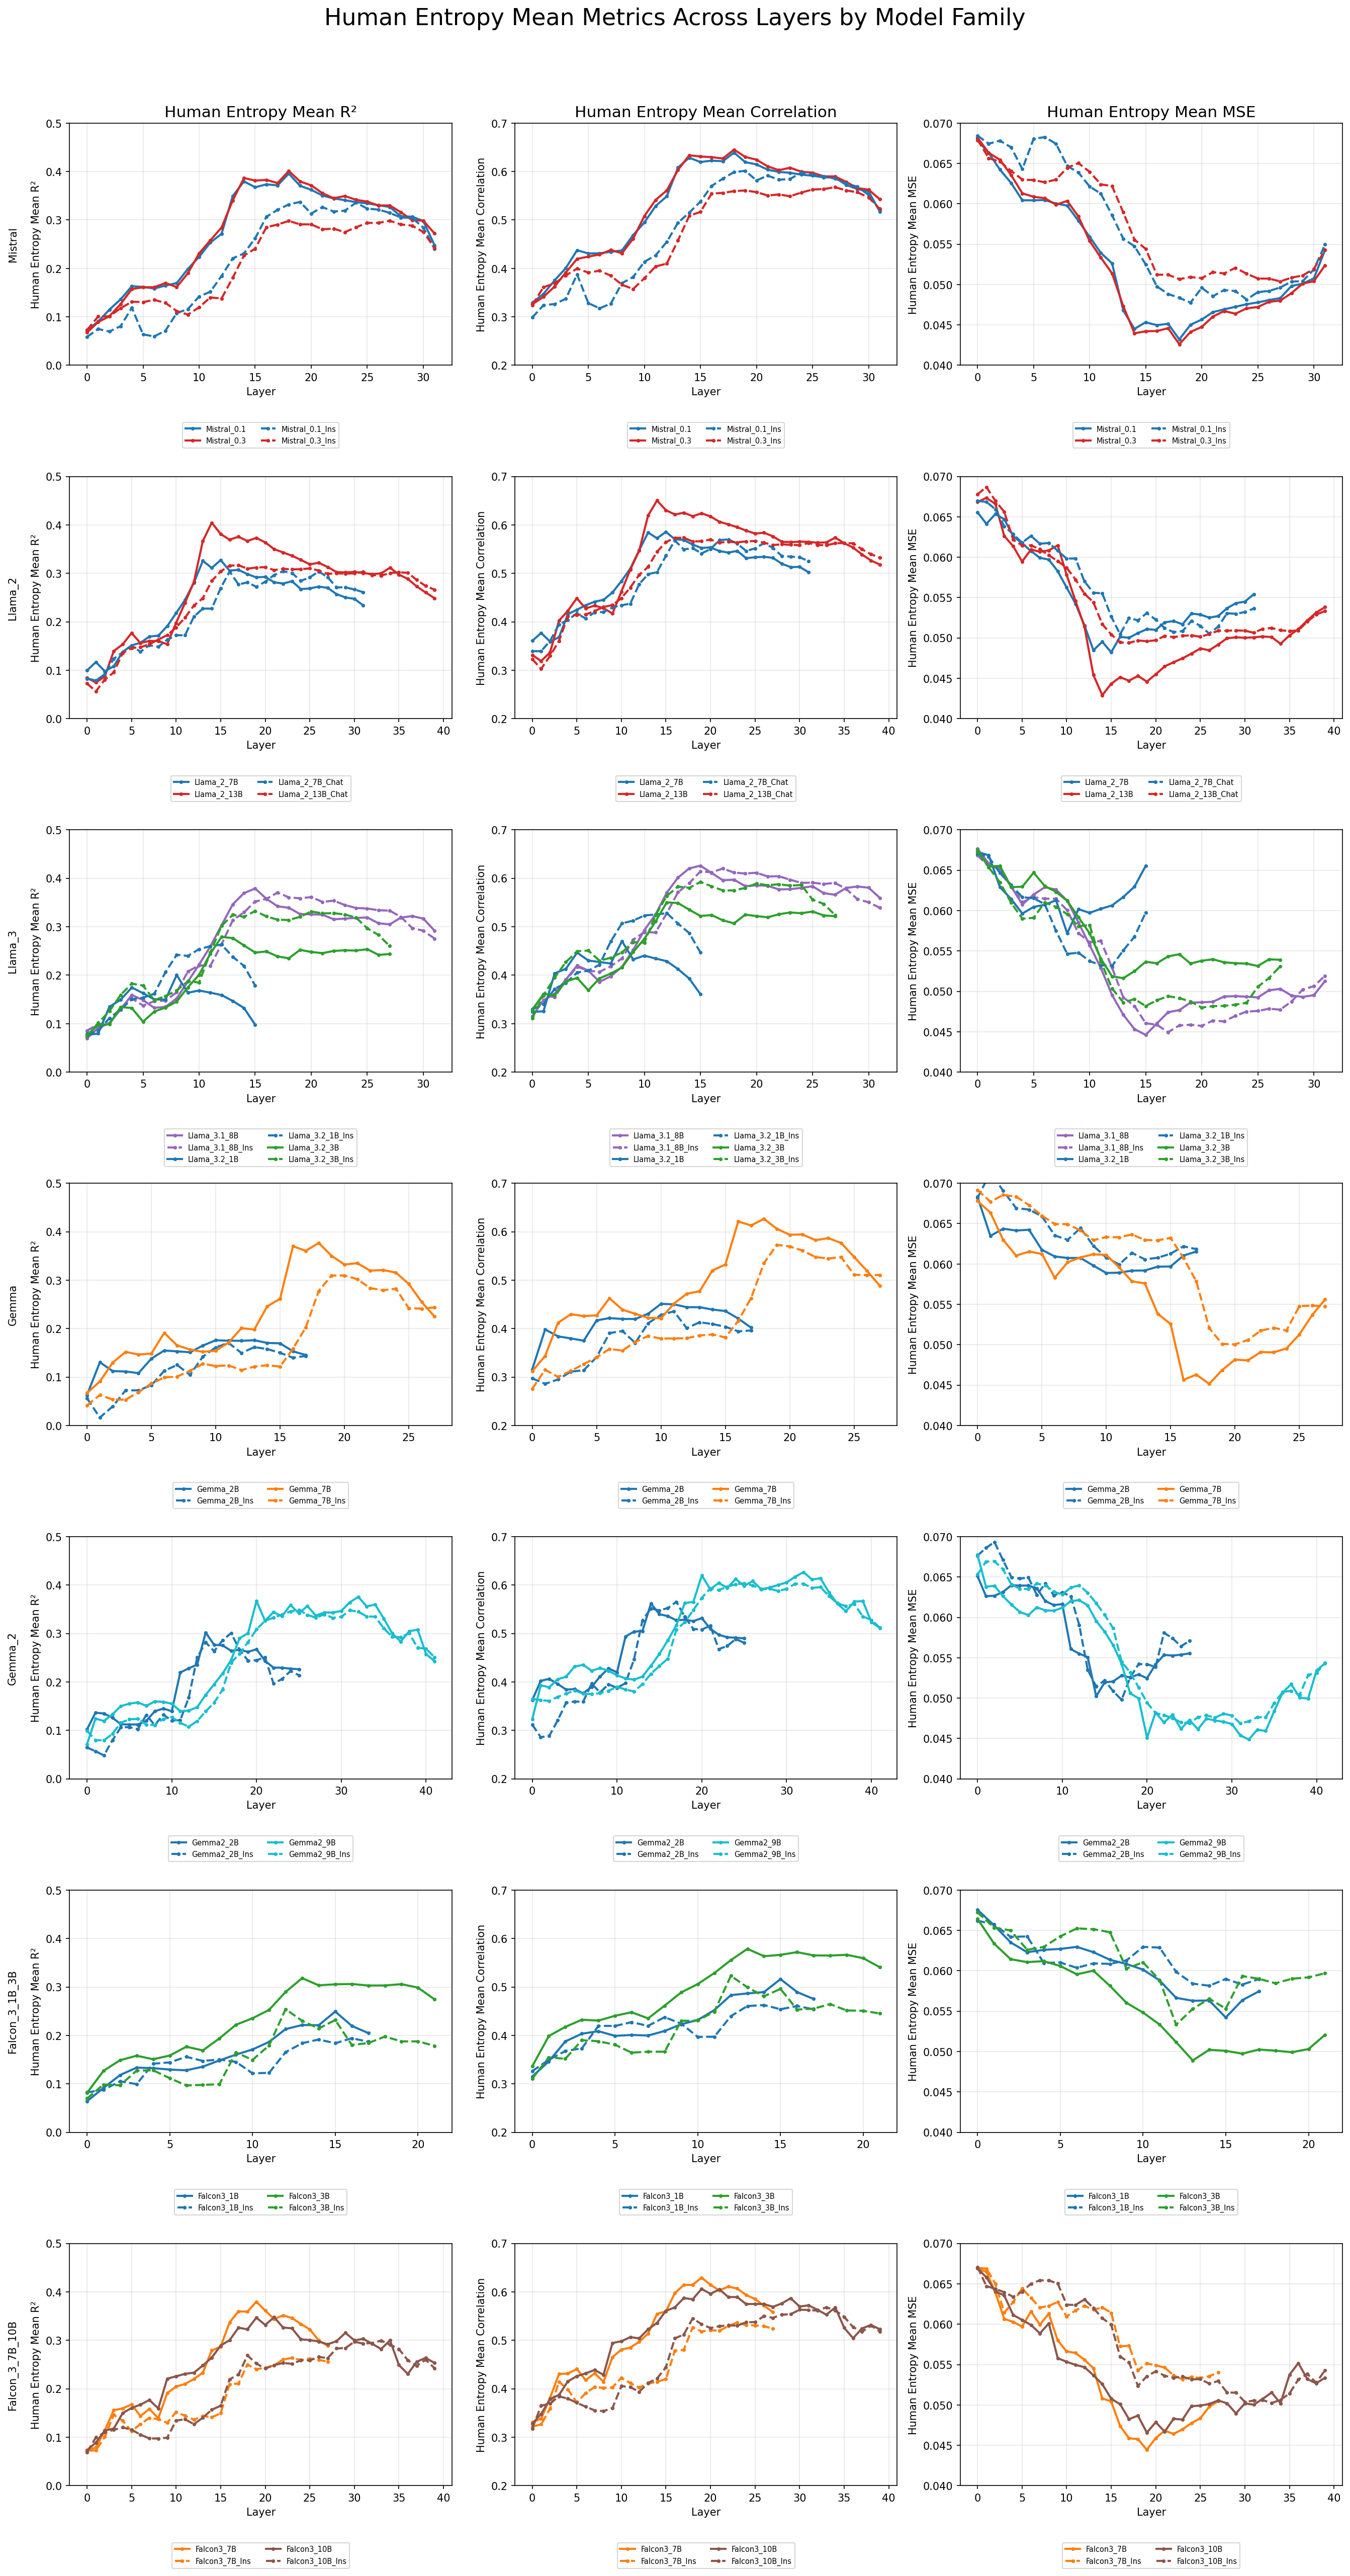


Done.


In [24]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Input path
# ============================================================

RESULTS_FILE = "LinearData/uncertainty_alignment_10fold_ridge_probe_results.csv"
# RESULTS_FILE = "LinearData/uncertainty_alignment_10fold_Results.csv"

# ============================================================
# Load CSV
# ============================================================

df = pd.read_csv(RESULTS_FILE)

print("Loaded file:", RESULTS_FILE)
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

# ============================================================
# Required columns
# ============================================================

model_col = "model"
layer_col = "layer"

if model_col not in df.columns:
    raise ValueError(f"Missing required column: {model_col}")

if layer_col not in df.columns:
    raise ValueError(f"Missing required column: {layer_col}")

# Convert layer_0, layer_1, layer_10, etc. into numeric layer values
df["layer_num"] = (
    df[layer_col]
    .astype(str)
    .str.replace("layer_", "", regex=False)
    .astype(int)
)

# ============================================================
# Human Entropy metrics only
# ============================================================

plot_metrics = [
    "human_ent_mean_r2",
    "human_ent_mean_correlation",
    "human_ent_mean_mse",
]

metric_titles = [
    "Human Entropy Mean R²",
    "Human Entropy Mean Correlation",
    "Human Entropy Mean MSE",
]

missing_metrics = [c for c in plot_metrics if c not in df.columns]

if missing_metrics:
    raise ValueError(f"These expected metric columns are missing: {missing_metrics}")

print("\nUsing metric columns:")
for c in plot_metrics:
    print("  ", c)

# ============================================================
# Model families
# model_type:
#   base = solid line
#   ins  = dashed line
# ============================================================

families = {
    "Mistral": [
        ("Mistral_0.1", "base", 7),
        ("Mistral_0.3", "base", 7),
        ("Mistral_0.1_Ins", "ins", 7),
        ("Mistral_0.3_Ins", "ins", 7),
    ],

    "Llama_2": [
        ("Llama_2_7B", "base", 7),
        ("Llama_2_13B", "base", 13),
        ("Llama_2_7B_Chat", "ins", 7),
        ("Llama_2_13B_Chat", "ins", 13),
    ],

    "Llama_3": [
        ("Llama_3.1_8B", "base", 8),
        ("Llama_3.1_8B_Ins", "ins", 8),
        ("Llama_3.2_1B", "base", 1),
        ("Llama_3.2_1B_Ins", "ins", 1),
        ("Llama_3.2_3B", "base", 3),
        ("Llama_3.2_3B_Ins", "ins", 3),
    ],

    "Gemma": [
        ("Gemma_2B", "base", 2),
        ("Gemma_2B_Ins", "ins", 2),
        ("Gemma_7B", "base", 7),
        ("Gemma_7B_Ins", "ins", 7),
    ],

    "Gemma_2": [
        ("Gemma2_2B", "base", 2),
        ("Gemma2_2B_Ins", "ins", 2),
        ("Gemma2_9B", "base", 9),
        ("Gemma2_9B_Ins", "ins", 9),
    ],

    "Falcon_3_1B_3B": [
        ("Falcon3_1B", "base", 1),
        ("Falcon3_1B_Ins", "ins", 1),
        ("Falcon3_3B", "base", 3),
        ("Falcon3_3B_Ins", "ins", 3),
    ],

    "Falcon_3_7B_10B": [
        ("Falcon3_7B", "base", 7),
        ("Falcon3_7B_Ins", "ins", 7),
        ("Falcon3_10B", "base", 10),
        ("Falcon3_10B_Ins", "ins", 10),
    ],
}

# ============================================================
# Plot styling
# ============================================================

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 10,
    "legend.fontsize": 7,
})

# Fallback colors by size
size_colors = {
    1:  "#1f77b4",
    2:  "#d62728",
    3:  "#2ca02c",
    7:  "#ff7f0e",
    8:  "#9467bd",
    9:  "#17becf",
    10: "#8c564b",
    13: "#e377c2",
}

# Better per-model colors
# Base/instruct pairs share a color, but different model versions/sizes get different colors
model_colors = {
    # Mistral
    "Mistral_0.1": "#1f77b4",
    "Mistral_0.1_Ins": "#1f77b4",
    "Mistral_0.3": "#d62728",
    "Mistral_0.3_Ins": "#d62728",

    # Llama 2
    "Llama_2_7B": "#1f77b4",
    "Llama_2_7B_Chat": "#1f77b4",
    "Llama_2_13B": "#d62728",
    "Llama_2_13B_Chat": "#d62728",

    # Llama 3
    "Llama_3.2_1B": "#1f77b4",
    "Llama_3.2_1B_Ins": "#1f77b4",
    "Llama_3.2_3B": "#2ca02c",
    "Llama_3.2_3B_Ins": "#2ca02c",
    "Llama_3.1_8B": "#9467bd",
    "Llama_3.1_8B_Ins": "#9467bd",

    # Gemma
    "Gemma_2B": "#1f77b4",
    "Gemma_2B_Ins": "#1f77b4",
    "Gemma_7B": "#ff7f0e",
    "Gemma_7B_Ins": "#ff7f0e",

    # Gemma 2
    "Gemma2_2B": "#1f77b4",
    "Gemma2_2B_Ins": "#1f77b4",
    "Gemma2_9B": "#17becf",
    "Gemma2_9B_Ins": "#17becf",

    # Falcon 3
    "Falcon3_1B": "#1f77b4",
    "Falcon3_1B_Ins": "#1f77b4",
    "Falcon3_3B": "#2ca02c",
    "Falcon3_3B_Ins": "#2ca02c",
    "Falcon3_7B": "#ff7f0e",
    "Falcon3_7B_Ins": "#ff7f0e",
    "Falcon3_10B": "#8c564b",
    "Falcon3_10B_Ins": "#8c564b",
}

# ============================================================
# Create one grid chart with all model families
# Rows = model families
# Columns = Human Entropy mean metrics
# ============================================================

n_families = len(families)
n_metrics = len(plot_metrics)

fig, axes = plt.subplots(
    nrows=n_families,
    ncols=n_metrics,
    figsize=(18, 5 * n_families),
    sharex=False
)

# Make sure axes is always 2D
if n_families == 1:
    axes = axes.reshape(1, -1)

for row_idx, (family_name, models) in enumerate(families.items()):

    family_model_names = [m[0] for m in models]
    family_df = df[df[model_col].isin(family_model_names)].copy()

    if family_df.empty:
        print(f"\nSkipping {family_name}: no matching rows found.")
        continue

    print(f"\nPlotting {family_name}...")

    for col_idx, metric in enumerate(plot_metrics):

        ax = axes[row_idx, col_idx]

        for model_name, model_type, size in models:

            model_df = family_df[family_df[model_col] == model_name].copy()

            if model_df.empty:
                print(f"  Missing model in results: {model_name}")
                continue

            model_df = model_df.sort_values("layer_num")

            linestyle = "-" if model_type == "base" else "--"
            color = model_colors.get(model_name, size_colors.get(size, None))

            ax.plot(
                model_df["layer_num"],
                model_df[metric],
                linestyle=linestyle,
                linewidth=2.0,
                marker="o",
                markersize=2.5,
                color=color,
                label=model_name,
            )

        # Column titles only on the top row
        if row_idx == 0:
            ax.set_title(metric_titles[col_idx], fontsize=15)

        # Put family name on the left-most plot of each row
        if col_idx == 0:
            ax.set_ylabel(f"{family_name}\n\n{metric_titles[col_idx]}")
        else:
            ax.set_ylabel(metric_titles[col_idx])

        ax.set_xlabel("Layer")
        ax.grid(True, alpha=0.3)

        # Fixed y-axis ranges
        if metric.endswith("_mean_correlation"):
            ax.set_ylim(0.2, 0.7)

        if metric.endswith("_mean_r2"):
            ax.set_ylim(0.0, 0.5)
        
        if metric.endswith("_mean_mse"):
            ax.set_ylim(0.04, 0.07)


        # Legend under each individual plot
        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.22),
            ncol=2,
            fontsize=7,
            frameon=True
        )

fig.suptitle(
    "Human Entropy Mean Metrics Across Layers by Model Family",
    fontsize=22,
    y=0.995
)

plt.tight_layout(rect=[0, 0.02, 1, 0.975])
plt.show()

print("\nDone.")